Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Read Input Data

In [10]:
df = pd.read_csv('uncleandata.csv')
df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,is_smoker,department,salary
0,0.38,0.53,2,157.0,3.0,0,yes,0,NaN,sales,low
1,0.80,0.86,5,262.0,6.0,0,yes,0,yes,sales,medium
2,0.11,0.88,7,272.0,4.0,0,yes,0,NaN,sales,medium
3,0.72,0.87,5,223.0,5.0,0,yes,0,NaN,sales,low
4,0.37,0.52,2,NaN,NaN,0,yes,0,no,sales,low
5,0.41,0.50,2,NaN,NaN,0,yes,0,NaN,sales,low
6,0.10,0.77,6,247.0,4.0,0,yes,0,NaN,sales,low
7,0.92,0.85,5,259.0,5.0,0,yes,0,NaN,sales,low
8,0.89,1.00,5,224.0,5.0,0,yes,0,NaN,sales,low
9,0.42,0.53,2,142.0,3.0,0,yes,0,NaN,sales,low


Q1. How many rows are there ?

In [11]:
print(f'The number of rows: {df.shape[0]}')

The number of rows: 15099


Q2. How many columns are there? What are they?

In [12]:
print(f'The number of columns: {df.shape[1]}')
columns_detailed = df.columns.to_list()
print(columns_detailed)

The number of columns: 11
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident', 'left', 'promotion_last_5years', 'is_smoker', 'department', 'salary']


Q3. How many features? What are they ?

In [13]:
target = 'left'
print(f'Number of features: {df.shape[1] - 1}') # Substract 1 to exclude target
for col in df.columns:
    if col != target:
        print(col)

Number of features: 10
satisfaction_level
last_evaluation
number_project
average_montly_hours
time_spend_company
work_accident
promotion_last_5years
is_smoker
department
salary


Q4. How many duplicates if any?

In [14]:
result = df.duplicated()
count_duplicate = 0
for item in result:
    if item == True:
        count_duplicate = count_duplicate + 1
print(f'Number of duplicates: {count_duplicate}')

Number of duplicates: 2840


Q5. Remove duplicates if there are any.

In [15]:
# Remove Duplicates
df.drop_duplicates(inplace = True)

# Check if Duplicates were removed
result = df.duplicated()
count_duplicate = 0
for item in result:
    if item == True:
        count_duplicate = count_duplicate + 1
print(f'Number of duplicates after removing: {count_duplicate}')

Number of duplicates after removing: 0


Q6. Print the distributions of each features. What do you see?

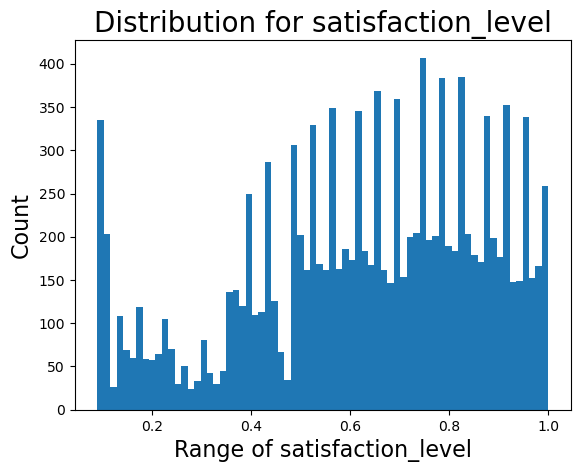

In [16]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["satisfaction_level"].plot(kind='hist', bins=70);

# Set title for diagram
feature.set_title('Distribution for satisfaction_level', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of satisfaction_level', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["satisfaction_level"]), max(df["satisfaction_level"]), 0.03));


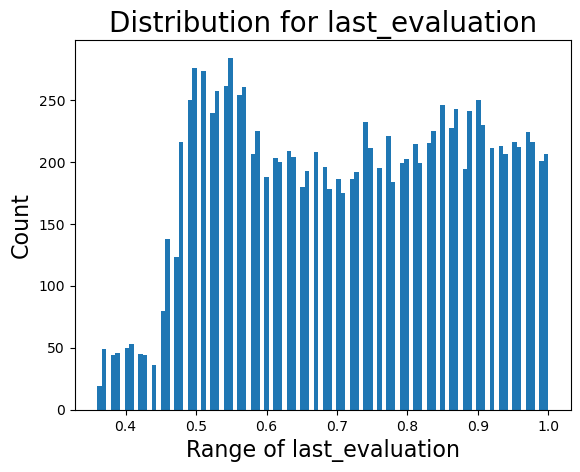

In [17]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["last_evaluation"].plot(kind='hist', bins=100);

# Set title for diagram
feature.set_title('Distribution for last_evaluation', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of last_evaluation', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["last_evaluation"]), max(df["last_evaluation"]), 0.03));

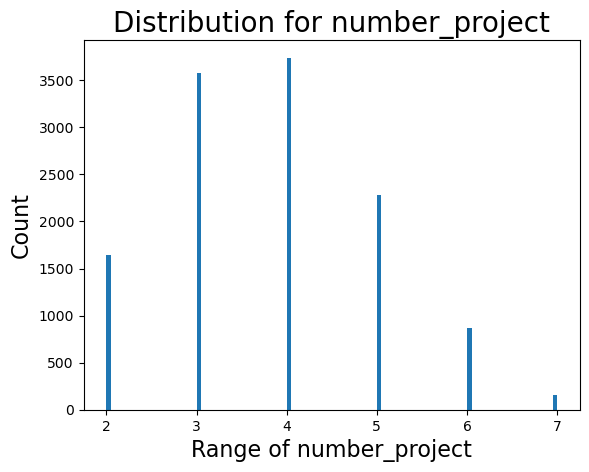

In [18]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["number_project"].plot(kind='hist', bins=100);

# Set title for diagram
feature.set_title('Distribution for number_project', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of number_project', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["number_project"]), max(df["number_project"]), 1));

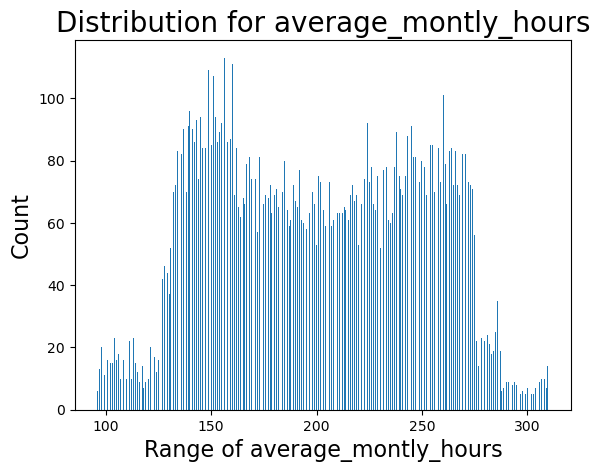

In [19]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["average_montly_hours"].plot(kind='hist', bins=500);

# Set title for diagram
feature.set_title('Distribution for average_montly_hours', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of average_montly_hours', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["average_montly_hours"]), max(df["number_project"]), 1));

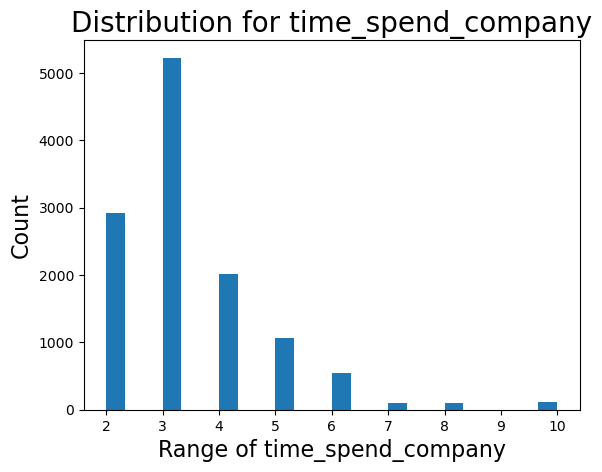

In [20]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["time_spend_company"].plot(kind='hist', bins=24);

# Set title for diagram
feature.set_title('Distribution for time_spend_company', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of time_spend_company', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["time_spend_company"]), max(df["time_spend_company"]), 1));

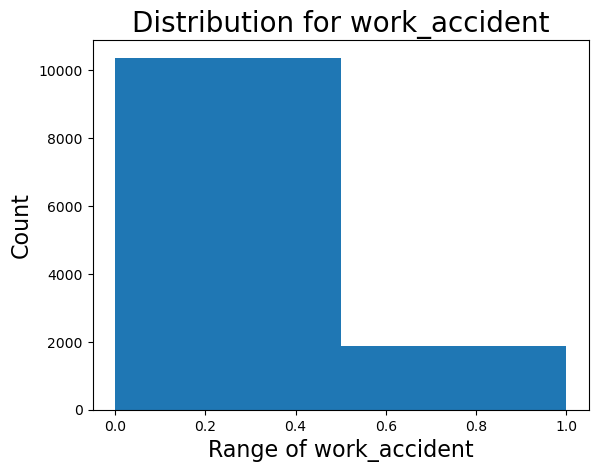

In [21]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["work_accident"].plot(kind='hist', bins=2);

# Set title for diagram
feature.set_title('Distribution for work_accident', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of work_accident', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["work_accident"]), max(df["work_accident"]), 0.5));

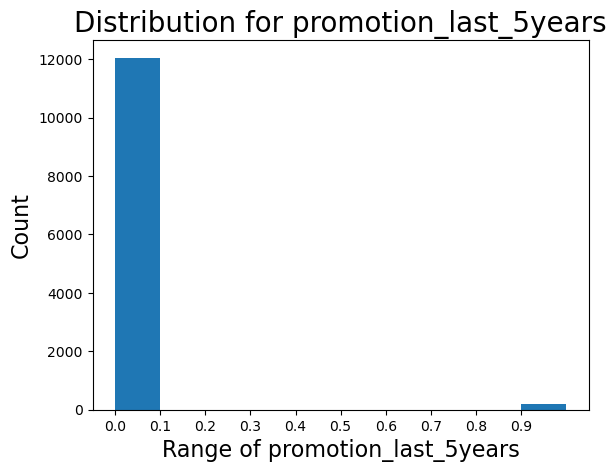

In [22]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram
feature = df["promotion_last_5years"].plot(kind='hist');

# Set title for diagram
feature.set_title('Distribution for promotion_last_5years', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of promotion_last_5years', fontsize=16);

# Set x-axis ticks 
plt.xticks(np.arange(min(df["promotion_last_5years"]), max(df["promotion_last_5years"]), 0.1));

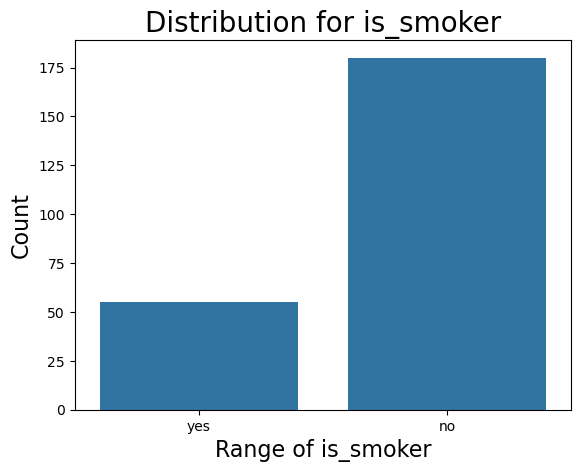

In [23]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 10));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram (when data is not numeric => using value_counts)
feature = sns.countplot(x=df["is_smoker"])

# Set title for diagram
feature.set_title('Distribution for is_smoker', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of is_smoker', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["is_smoker"]), max(df["is_smoker"]), 0.5));

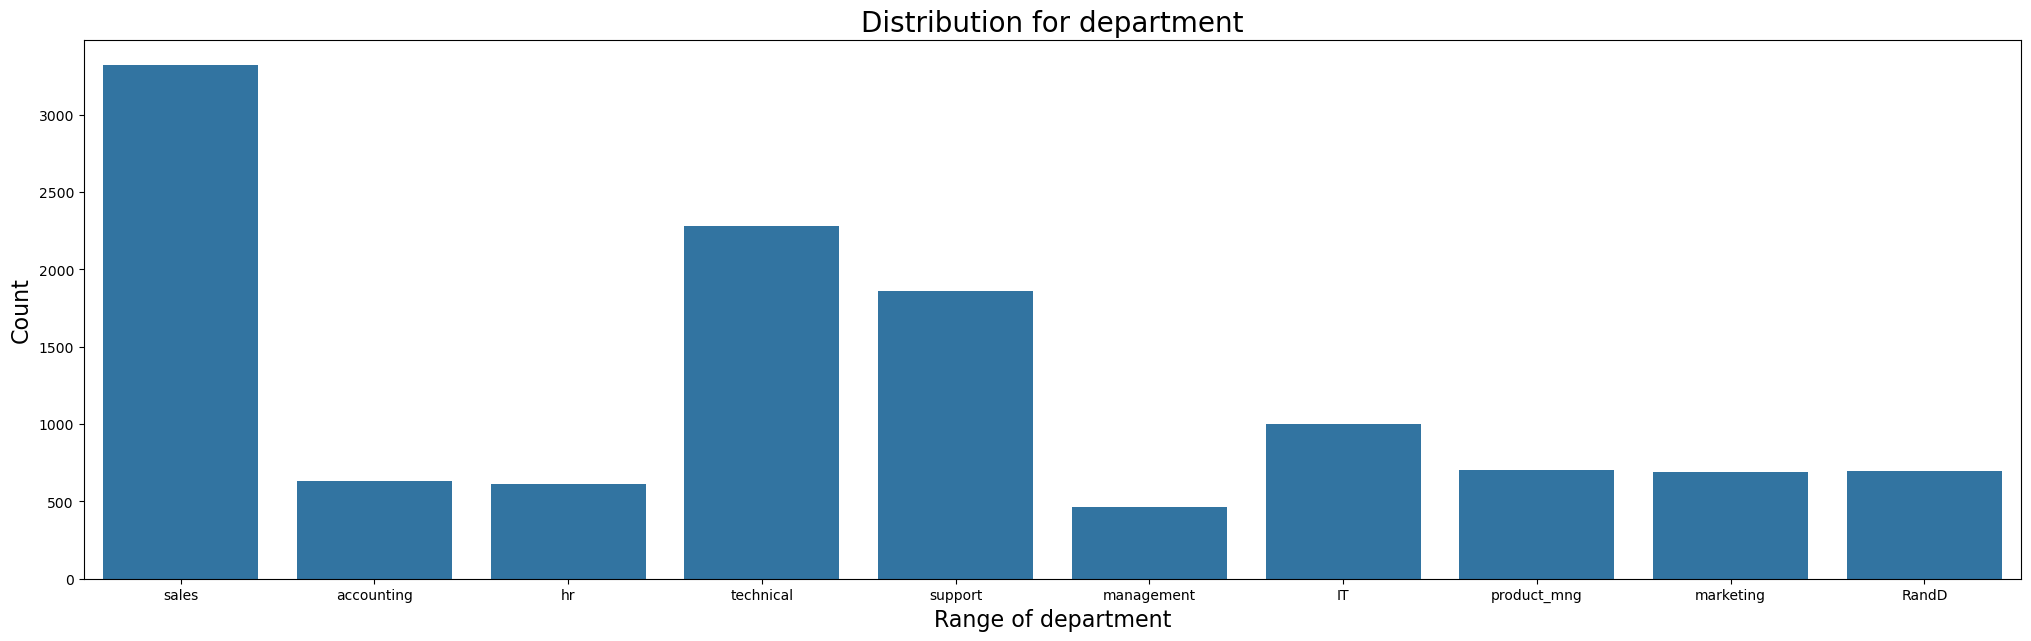

In [24]:
# Set the figure size before creating the plot
plt.figure(figsize=(25, 7));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram (when data is not numeric => using value_counts)
feature = sns.countplot(x=df["department"])

# Set title for diagram
feature.set_title('Distribution for department', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of department', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["department"]), max(df["department"]), 0.5));

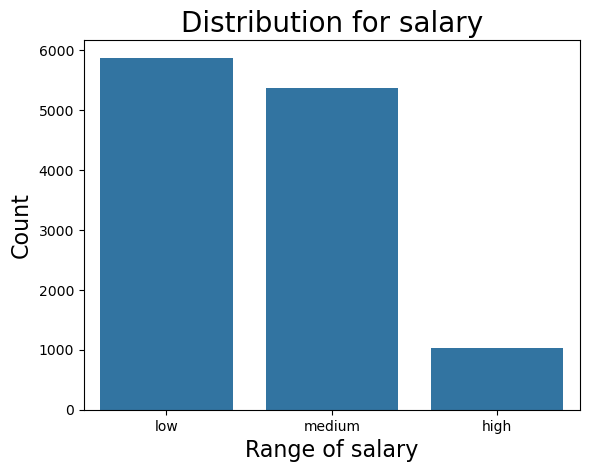

In [25]:
# # Set the figure size before creating the plot
# plt.figure(figsize=(25, 7));  # Width: 10 inches, Height: 6 inches

# Draw historical diagram (when data is not numeric => using value_counts)
feature = sns.countplot(x=df["salary"])

# Set title for diagram
feature.set_title('Distribution for salary', fontsize=20);

# Label x-axis and y-axis
feature.set_ylabel('Count', fontsize=16);
feature.set_xlabel('Range of salary', fontsize=16);

# Set x-axis ticks 
# plt.xticks(np.arange(min(df["salary"]), max(df["salary"]), 0.5));

Q7.How many missing values are there? What features have missing values?

In [26]:
# Count total missing values for each columns 
num_miss_values = []
for col in df.columns:
    print(f'The number of missing values of {col}: {df[col].isna().sum()}')

# Count total missing values for entire data
print(f'The total number of missing values for entire data: {df.isna().sum().sum()}')

The number of missing values of satisfaction_level: 0
The number of missing values of last_evaluation: 0
The number of missing values of number_project: 0
The number of missing values of average_montly_hours: 368
The number of missing values of time_spend_company: 150
The number of missing values of work_accident: 0
The number of missing values of left: 0
The number of missing values of promotion_last_5years: 0
The number of missing values of is_smoker: 12024
The number of missing values of department: 0
The number of missing values of salary: 0
The total number of missing values for entire data: 12542


Q8. Drop the features with largest number of missing values and fill up the rest of the features with missing values with mean. 
Can you explain why did we drop the feature with largest portion of missing values in this case?

1. Drop the features with largest number of missing values.

In [27]:
# Find columns having largest number of missing values
to_delete_columns = []
for col in df.columns:
    if df[col].isna().sum() == df[df.columns].isna().sum().max():
        to_delete_columns.append(col)

# Delete those columns
clean_data = df.drop(columns= to_delete_columns)

# View new data
clean_data.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157.0,3.0,0,yes,0,sales,low
1,0.80,0.86,5,262.0,6.0,0,yes,0,sales,medium
2,0.11,0.88,7,272.0,4.0,0,yes,0,sales,medium
3,0.72,0.87,5,223.0,5.0,0,yes,0,sales,low
4,0.37,0.52,2,NaN,NaN,0,yes,0,sales,low
5,0.41,0.50,2,NaN,NaN,0,yes,0,sales,low
6,0.10,0.77,6,247.0,4.0,0,yes,0,sales,low
7,0.92,0.85,5,259.0,5.0,0,yes,0,sales,low
8,0.89,1.00,5,224.0,5.0,0,yes,0,sales,low
9,0.42,0.53,2,142.0,3.0,0,yes,0,sales,low


2. Fill up the rest of the features with missing values with mean.

In [28]:
# Only fill up numeric columns
for col in clean_data.columns:
    # Check if the column contains numeric data
    if pd.api.types.is_numeric_dtype(clean_data[col]):                 
        # Calculate the average value of the numeric column
        avg_val = clean_data[col].mean()
        
        # Fill NaN values in the column with the calculated average
        clean_data[col] = clean_data[col].fillna(avg_val)

# View data after filling up
clean_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157.000000,3.000000,0,yes,0,sales,low
1,0.80,0.86,5,262.000000,6.000000,0,yes,0,sales,medium
2,0.11,0.88,7,272.000000,4.000000,0,yes,0,sales,medium
3,0.72,0.87,5,223.000000,5.000000,0,yes,0,sales,low
4,0.37,0.52,2,200.511732,3.380048,0,yes,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14968,0.40,0.47,2,128.000000,3.000000,0,yes,0,sales,medium
14969,0.43,0.46,2,157.000000,3.000000,0,yes,0,sales,medium
14990,0.89,0.88,5,228.000000,5.000000,1,yes,0,support,low
14993,0.76,0.83,6,293.000000,6.000000,0,yes,0,support,low


Q9. Show that there are no missing values in the data at this point.

In [29]:
print("The number of missing value for each 'NUMERIC' column:")
for col in clean_data.columns:
    # Check if the column contains numeric data
    if pd.api.types.is_numeric_dtype(clean_data[col]): 
        print(f'{col}: {clean_data[col].isna().sum()}')

The number of missing value for each 'NUMERIC' column:
satisfaction_level: 0
last_evaluation: 0
number_project: 0
average_montly_hours: 0
time_spend_company: 0
work_accident: 0
promotion_last_5years: 0


Q10. Feature "left" has values 'yes' and 'no'.Convert those values into integer values, 1 and 0.

In [30]:
clean_data['left'] = clean_data['left'].map({'yes': 1, 'no': 0})
clean_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157.000000,3.000000,0,1,0,sales,low
1,0.80,0.86,5,262.000000,6.000000,0,1,0,sales,medium
2,0.11,0.88,7,272.000000,4.000000,0,1,0,sales,medium
3,0.72,0.87,5,223.000000,5.000000,0,1,0,sales,low
4,0.37,0.52,2,200.511732,3.380048,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14968,0.40,0.47,2,128.000000,3.000000,0,1,0,sales,medium
14969,0.43,0.46,2,157.000000,3.000000,0,1,0,sales,medium
14990,0.89,0.88,5,228.000000,5.000000,1,1,0,support,low
14993,0.76,0.83,6,293.000000,6.000000,0,1,0,support,low


Q11. Save the resulting data into a file.

In [31]:
clean_data.to_csv('clean_data.csv', index = False)

Q12. What else do you observe in in this data set.

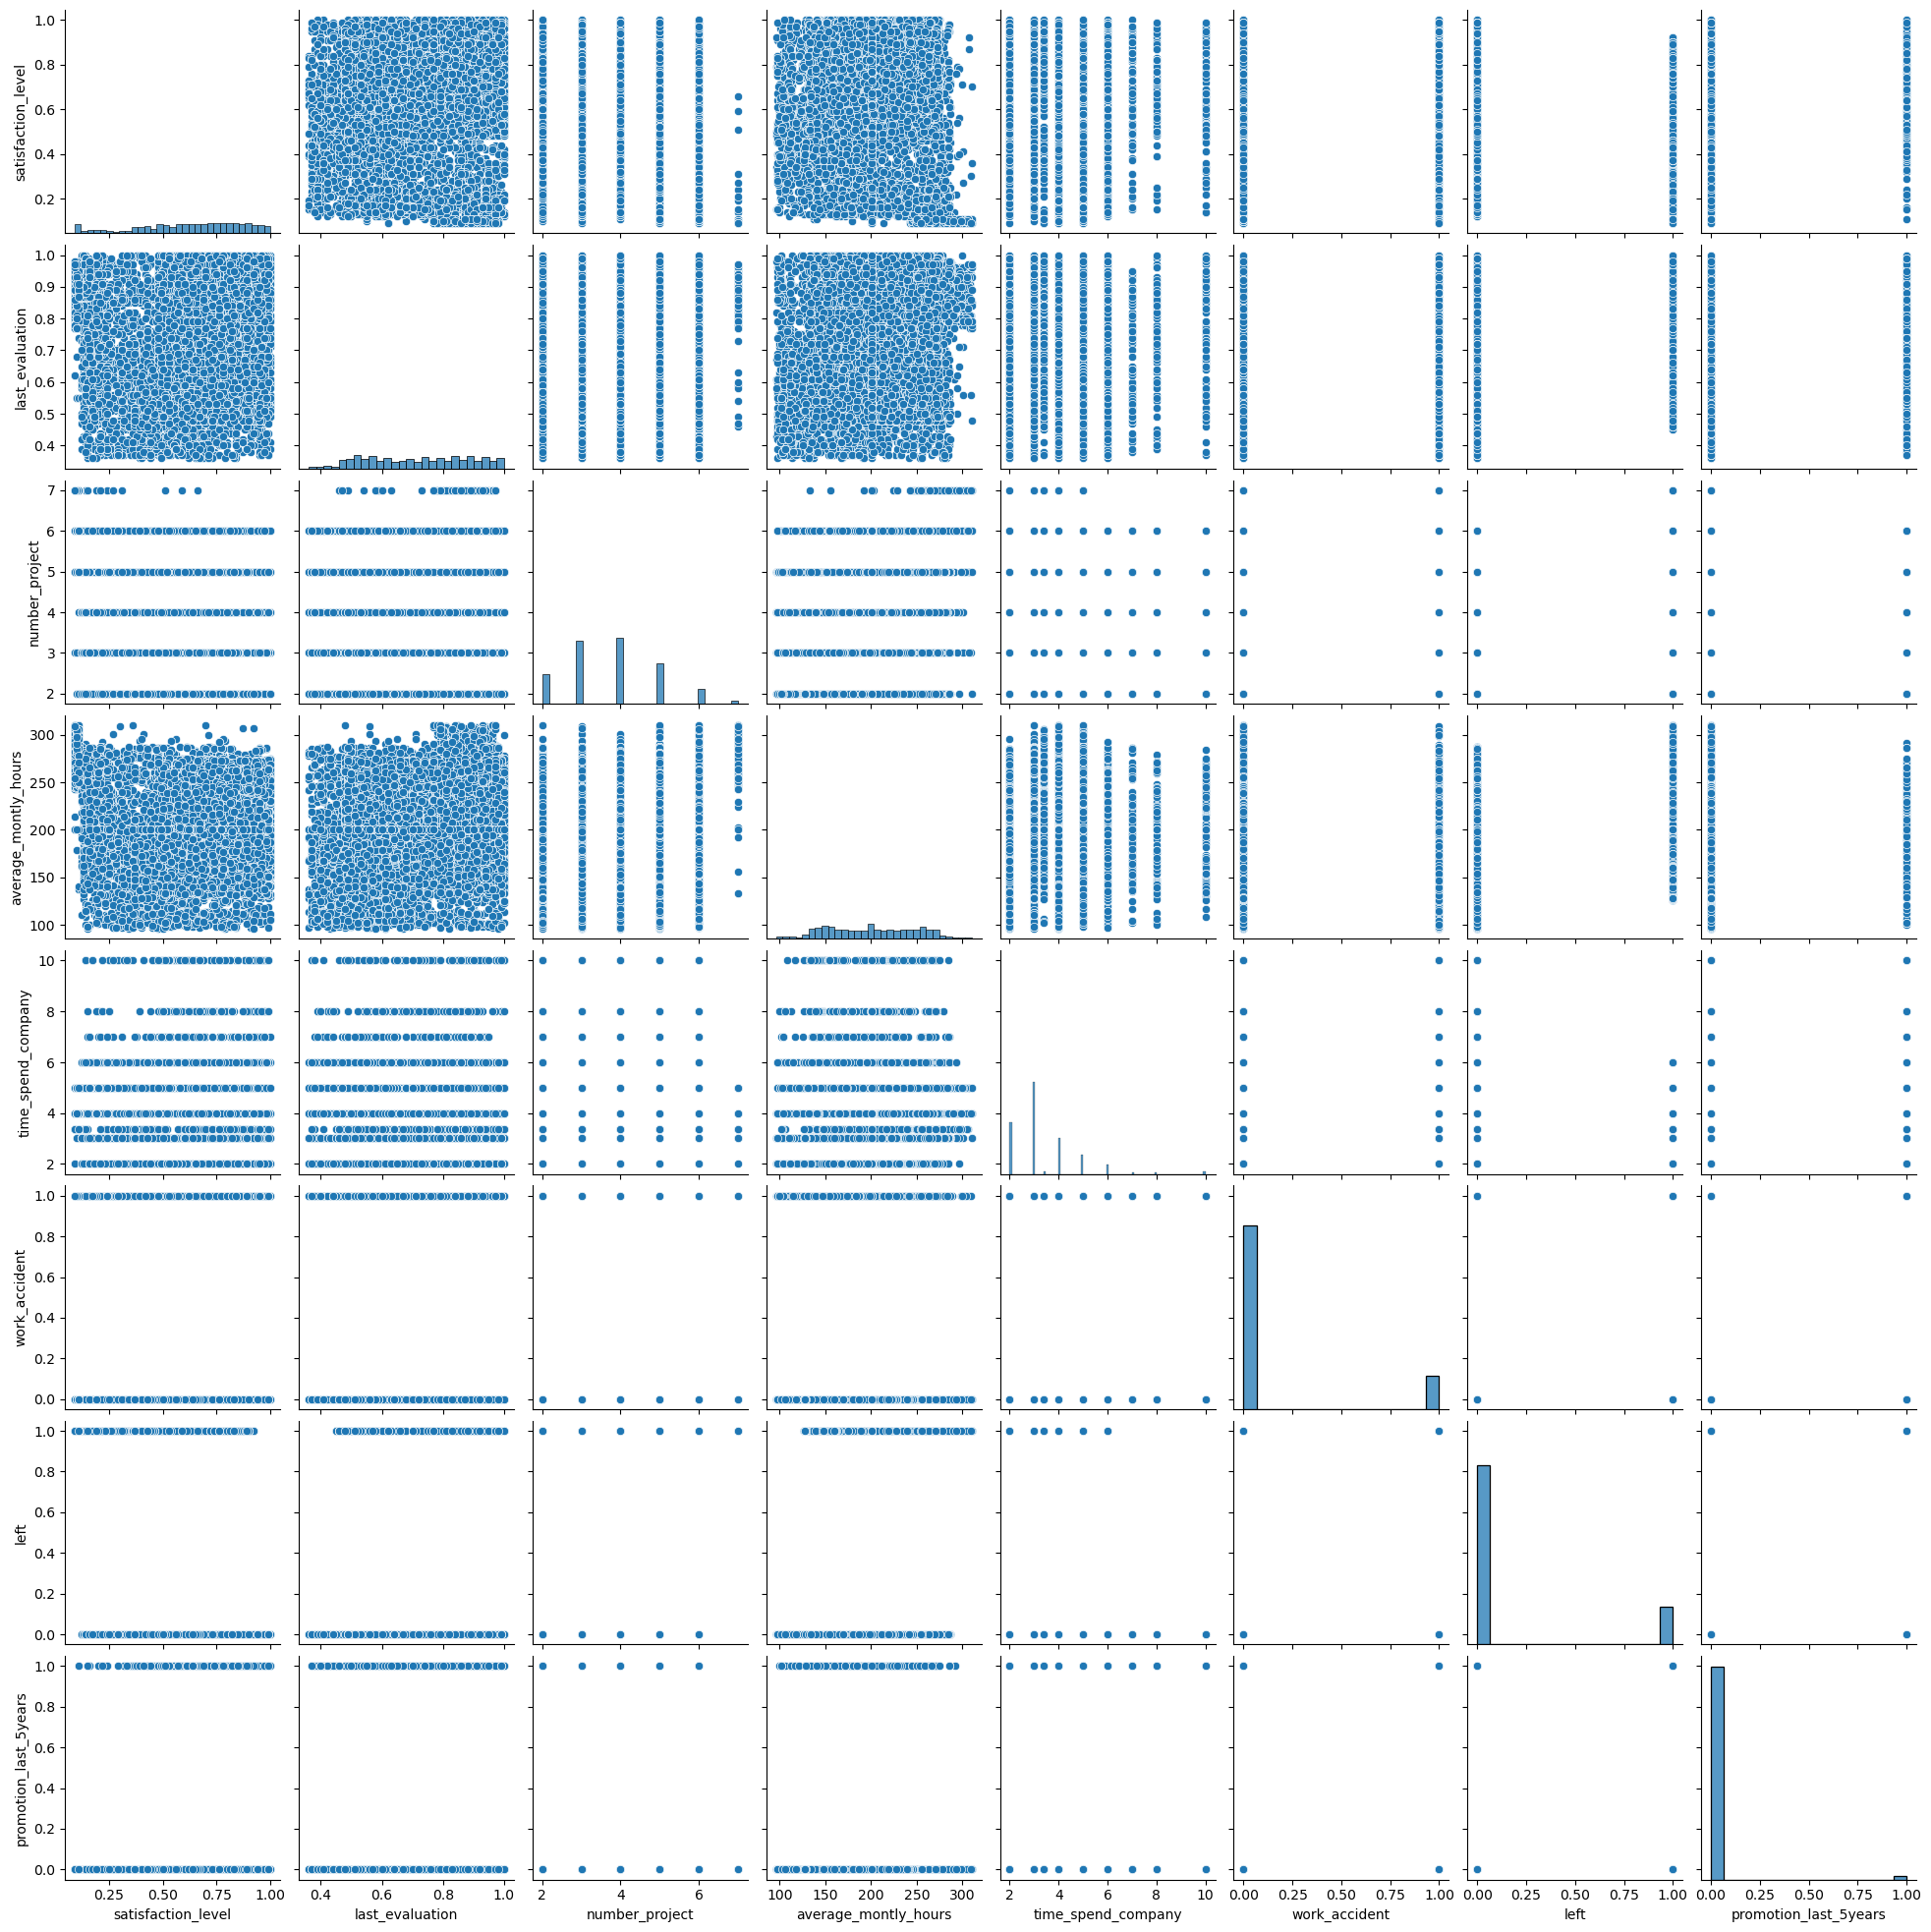

In [32]:
sns.pairplot(clean_data[clean_data.columns])

Q13. Divide the data into training set(80%) and test set(20%) and show the number of data points in each by following

1. Uniform sampling

In [33]:
uniform_training_set, uniform_testing_set = train_test_split(clean_data,test_size=0.2, random_state=42)

2. Stratified sampling based on the ratio of "yes" and "no" values of feature "left"

In [34]:
stratified_training_set,stratified_testing_set = train_test_split(clean_data,test_size=0.2,stratify=clean_data['left'])

3. How would you do the test set and training set sampling and why ?